# Solemne — Optimización (CINF105) · 2026

**Distribución de combustibles con flota de camiones cisterna de doble compartimento**

Resolución mediante **metaheurística en Python** (Algoritmo Genético) + verificación exacta.

| | |
|---|---|
| **Nombre** |Vicente Díaz - Eduardo Zepeda - Fernando Chávez|
| **NRC** |7924|
| **RUT** |21761195-4 -- 20834105-7 -- 21777267-2 |
| **Enfoque** | Metaheurística en Python -- Algoritmo Genetico|

---

### Contenido
1. **Parte 1** — Modelo MILP determinista (formulación + metaheurística, escenario s=1)
2. **Parte 2** — Scheduling de carga en el depósito (makespan + Gantt)
3. **Parte 3** — Análisis de la solución propuesta por el operador (factibilidad y costo)
4. **Parte 4** — Extensión estocástica de dos etapas (3 escenarios)

> **Nota metodológica.** El enunciado permite entregar en *AMPL o metaheurística en Python*. Aquí se opta por la metaheurística, lo que permite **ejecutar realmente** el notebook y reproducir todos los resultados. Para cada parte que admite optimización combinatoria se incluye además una **resolución exacta por enumeración** (el problema es pequeño) que sirve para **validar** que la metaheurística alcanza el óptimo.


## 0. Datos y parámetros del problema

Se codifican todos los datos del enunciado. El **depósito** es el nodo `0` y las estaciones son `1..4`.
Las velocidades son de 60 km/h = **1 km/min**, por lo que distancia en km equivale a tiempo en minutos.
El tiempo se mide en **minutos desde la medianoche** (p.ej. 05:00 = 300).

In [1]:

import itertools, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42); np.random.seed(42)

# --- Nodos ---
DEPOT = 0
STATIONS = [1, 2, 3, 4]

# --- Matriz de distancias (km), simetrica ---
DIST = np.array([
    [ 0, 20, 35, 15, 40],   # Deposito
    [20,  0, 10, 25, 30],   # Est 1
    [35, 10,  0, 20, 15],   # Est 2
    [15, 25, 20,  0, 30],   # Est 3
    [40, 30, 15, 30,  0],   # Est 4
], dtype=float)

# --- Parametros globales ---
SERVICE = 30.0       # min de servicio por estacion
SPEED   = 1.0        # km/min  (60 km/h)
DELTA   = 0.30       # estabilidad de carga (diferencia maxima de fill ratios)
C_DIST  = 2.0        # $/km
C_SHORT = 10.0       # $/L no entregado

# --- Ventanas de tiempo [a_j, b_j] en minutos desde 00:00 ---
WIN = {1:(360,600),   # 06:00-10:00
       2:(420,720),   # 07:00-12:00
       3:(480,840),   # 08:00-14:00
       4:(360,660)}   # 06:00-11:00

# --- Flota: compartimentos C0/C1, costo fijo, hora de salida (min) ---
TRUCKS = {
    'T1': {'caps': (8000, 7000), 'fixed': 500, 'depart': 300},  # 05:00
    'T2': {'caps': (6000, 9000), 'fixed': 400, 'depart': 330},  # 05:30
}

# --- Demanda escenario s=1 (Normal): (Regular, Diesel) por estacion ---
DEM_S1 = {1:(3000,2000), 2:(4000,1500), 3:(2500,3000), 4:(1000,2500)}

def hhmm(m):
    "minutos -> 'HH:MM'"
    m = int(round(m)); return f"{m//60:02d}:{m%60:02d}"

print("Demanda total escenario s=1:")
print("  Regular =", sum(d[0] for d in DEM_S1.values()), "L")
print("  Diesel  =", sum(d[1] for d in DEM_S1.values()), "L")
print("Capacidad total de la flota =", sum(sum(t['caps']) for t in TRUCKS.values()), "L")


Demanda total escenario s=1:
  Regular = 10500 L
  Diesel  = 9000 L
Capacidad total de la flota = 30000 L


## Parte 1 — Modelamiento determinista (MILP)

### a) Conjuntos y parámetros

**Conjuntos**

| Símbolo | Descripción |
|---|---|
| $N=\{0,1,2,3,4\}$ | nodos; $0$ = depósito |
| $C=\{1,2,3,4\}$ | estaciones de servicio |
| $K=\{T1,T2\}$ | camiones |
| $P=\{R,D\}$ | productos: Regular, Diésel |
| $M=\{0,1\}$ | compartimentos de cada camión |

**Parámetros**

| Símbolo | Descripción |
|---|---|
| $d_{ij}$ | distancia (km) entre nodos $i,j$ |
| $Dem_{jp}$ | demanda del producto $p$ en la estación $j$ (L) |
| $Q_{km}$ | capacidad del compartimento $m$ del camión $k$ (L) |
| $F_k$ | costo fijo de usar el camión $k$ (\$) |
| $cf$ | costo por km \$2; $cs$ penalización \$10/L |
| $[a_j,b_j]$ | ventana de tiempo de la estación $j$ |
| $\tau=30$ | tiempo de servicio (min); $v=60$ km/h |
| $\Delta=0.30$ | diferencia máxima de fill ratios en un mismo camión |

### b) Variables de decisión

| Variable | Tipo | Interpretación |
|---|---|---|
| $x_{ijk}\in\{0,1\}$ | binaria | el camión $k$ recorre el arco $i\to j$ |
| $z_k\in\{0,1\}$ | binaria | el camión $k$ es utilizado |
| $\alpha_{kmp}\in\{0,1\}$ | binaria | el compartimento $m$ del camión $k$ transporta el producto $p$ |
| $L_{kmp}\ge 0$ | continua | litros del producto $p$ cargados en el compart. $m$ del camión $k$ |
| $q_{jkp}\ge 0$ | continua | litros del producto $p$ entregados a $j$ por el camión $k$ |
| $w_{jp}\ge 0$ | continua | litros de $p$ **no** entregados (shortage) en $j$ |
| $t_{jk}\ge 0$ | continua | hora de llegada del camión $k$ a la estación $j$ |
| $r_{jkm}\in[0,1]$ | continua | fill ratio del compart. $m$ del camión $k$ al **salir** de $j$ |
| $\mu_{ik}\ge 0$ | continua | variable MTZ (eliminación de subtours) |

### c) Función objetivo

$$\min\; \underbrace{\sum_{k} F_k\,z_k}_{\text{costo fijo}}\;+\;\underbrace{cf\sum_{i,j,k} d_{ij}\,x_{ijk}}_{\text{costo de distancia}}\;+\;\underbrace{cs\sum_{j,p} w_{jp}}_{\text{penalización por shortage}}$$

### d) Restricciones

**Conservación de flujo / routing**

$$\sum_{j} x_{jik}=\sum_{j} x_{ijk}\quad \forall i\in N,\,k \qquad\text{(grado de entrada = grado de salida)}$$
$$\sum_{j} x_{0jk}=z_k \quad\forall k \qquad \sum_{k}\sum_{i} x_{ijk}\le 1\;\;\forall j\in C$$
$$\mu_{ik}-\mu_{jk}+|C|\,x_{ijk}\le |C|-1 \quad \forall i,j\in C,\,k \qquad\text{(MTZ, anti-subtour)}$$

**Compatibilidad compartimento–producto** (cada compartimento lleva a lo más un producto)

$$\sum_{p}\alpha_{kmp}\le 1\quad\forall k,m \qquad L_{kmp}\le Q_{km}\,\alpha_{kmp}\quad\forall k,m,p$$

**Capacidad de cada compartimento**

$$\sum_{p} L_{kmp}\le Q_{km}\quad\forall k,m \qquad \sum_{j} q_{jkp}\le \sum_{m} L_{kmp}\quad\forall k,p$$

**Satisfacción de demanda con shortage**

$$\sum_{k} q_{jkp} + w_{jp} = Dem_{jp}\quad\forall j\in C,\,p\in P$$

**Ventanas de tiempo** (con $t_{0k}=$ hora de salida del camión $k$)

$$t_{jk}\ge t_{ik}+\tau+\tfrac{d_{ij}}{v} - M(1-x_{ijk}) \qquad a_j\le t_{jk}\le b_j \;\;\text{si }j\text{ es visitada}$$

**Estabilidad de carga** ($\Delta=0.30$, en cada instante = al salir del depósito y tras cada entrega)

$$\big|\,r_{jk0}-r_{jk1}\,\big|\le \Delta\quad\forall j\in\{0\}\cup C,\,k,\qquad r_{jkm}=\frac{\text{volumen remanente en }(k,m)\text{ al salir de }j}{Q_{km}}$$

> Como el problema es pequeño, abajo se resuelve con un **Algoritmo Genético** (metaheurística) y se valida contra **enumeración exacta**. La decisión de carga se fija a $L=\min(\text{demanda asignada},\,\text{capacidad})$, que es óptima cuando el shortage es muy costoso.

In [2]:

# ============================================================
#  MOTOR DE EVALUACION  (compartido por Partes 1, 3 y 4)
# ============================================================
def eval_truck(tname, order, reg_comp, demand, loads=None):
    # Simula la ruta de un camion.
    #   order    : lista ordenada de estaciones visitadas
    #   reg_comp : compartimento (0/1) que lleva REGULAR (el otro lleva DIESEL)
    #   demand   : {est:(reg,die)}
    #   loads    : (load_reg, load_die) ; si None -> min(demanda, capacidad)
    t = TRUCKS[tname]; caps = t['caps']; die_comp = 1 - reg_comp
    cap_reg, cap_die = caps[reg_comp], caps[die_comp]
    dem_reg = sum(demand[s][0] for s in order)
    dem_die = sum(demand[s][1] for s in order)
    if loads is None:
        load_reg, load_die = min(dem_reg, cap_reg), min(dem_die, cap_die)
    else:
        load_reg, load_die = min(loads[0], cap_reg), min(loads[1], cap_die)

    rem = [0.0, 0.0]; rem[reg_comp] = load_reg; rem[die_comp] = load_die
    fills = [(rem[0]/caps[0], rem[1]/caps[1])]      # instante 0 = salida del deposito
    instants = ['Salida deposito']
    short = 0.0; arrivals = {}; late = False
    t_now = t['depart']; prev = DEPOT
    for s in order:
        t_now += DIST[prev, s] / SPEED
        arrivals[s] = t_now
        a, b = WIN[s]
        if t_now > b + 1e-6: late = True
        t_now = max(t_now, a) + SERVICE          # se permite esperar si llega antes de a_j
        dr = min(rem[reg_comp], demand[s][0]); rem[reg_comp] -= dr; short += demand[s][0]-dr
        dd = min(rem[die_comp], demand[s][1]); rem[die_comp] -= dd; short += demand[s][1]-dd
        fills.append((rem[0]/caps[0], rem[1]/caps[1]))
        instants.append(f"Tras Est.{s}")
        prev = s
    t_now += DIST[prev, DEPOT] / SPEED
    dist = sum(DIST[a, b] for a, b in zip([DEPOT]+order, order+[DEPOT]))
    stab_ok = all(abs(f0-f1) <= DELTA + 1e-9 for f0, f1 in fills)
    return dict(dist=dist, short=short, fills=fills, instants=instants,
                arrivals=arrivals, late=late, stab_ok=stab_ok, return_time=t_now,
                load_reg=load_reg, load_die=load_die, cap_reg=cap_reg, cap_die=cap_die,
                reg_comp=reg_comp)

def eval_solution(routes, orient, demand, loads=None):
    # routes={'T1':[...], 'T2':[...]}, orient={'T1':reg_comp,...}
    tot_d = tot_s = fixed = 0.0; stab = tw = True; info = {}
    for tname, order in routes.items():
        if not order: continue
        L = None if loads is None else loads.get(tname)
        r = eval_truck(tname, order, orient[tname], demand, L)
        info[tname] = r
        tot_d += r['dist']; tot_s += r['short']; fixed += TRUCKS[tname]['fixed']
        stab = stab and r['stab_ok']; tw = tw and (not r['late'])
    return dict(total=C_DIST*tot_d + fixed + C_SHORT*tot_s,
                dist=tot_d, dist_cost=C_DIST*tot_d, fixed=fixed,
                short=tot_s, short_cost=C_SHORT*tot_s,
                stab_ok=stab, tw_ok=tw, info=info)

def best_order(tname, stations, reg_comp, demand, penalty=1e7):
    # Mejor orden de visita (enumera permutaciones; estaciones <= 4).
    best = None
    for perm in itertools.permutations(stations):
        r = eval_truck(tname, list(perm), reg_comp, demand)
        pen = 0 if (r['stab_ok'] and not r['late']) else penalty
        score = C_DIST*r['dist'] + C_SHORT*r['short'] + pen
        if best is None or score < best[0]:
            best = (score, list(perm), r)
    return best

print("Motor de evaluacion cargado.")


Motor de evaluacion cargado.


### Resolución exacta (enumeración) — referencia óptima

Hay $2^4=16$ formas de asignar las 4 estaciones a 2 camiones y $2\times2$ orientaciones de compartimentos; para cada una se elige el mejor orden de visita. Esto da el óptimo global de referencia.

In [3]:

def solve_exact(demand):
    best = None
    for assign in itertools.product(['T1','T2'], repeat=4):
        st = {'T1':[], 'T2':[]}
        for i, s in enumerate(STATIONS): st[assign[i]].append(s)
        for o1 in (0,1):
            for o2 in (0,1):
                orient = {'T1':o1, 'T2':o2}; routes = {}
                for tn in ('T1','T2'):
                    routes[tn] = best_order(tn, st[tn], orient[tn], demand)[1] if st[tn] else []
                res = eval_solution(routes, orient, demand)
                feas = res['stab_ok'] and res['tw_ok']
                key = (0 if feas else 1, res['total'])
                if best is None or key < best[0]:
                    best = (key, routes, orient, res)
    return best

key, routes_opt, orient_opt, res_opt = solve_exact(DEM_S1)
print("===== OPTIMO EXACTO (escenario s=1) =====")
for tn in ('T1','T2'):
    if routes_opt[tn]:
        rc = 'C0' if orient_opt[tn]==0 else 'C1'
        print(f"  {tn}: Deposito -> {' -> '.join('Est'+str(s) for s in routes_opt[tn])} -> Deposito"
              f"   | Regular en {rc}")
print(f"  Distancia total = {res_opt['dist']:.0f} km")
print(f"  Costo distancia = ${res_opt['dist_cost']:.0f} | Costo fijo = ${res_opt['fixed']:.0f} "
      f"| Shortage = {res_opt['short']:.0f} L (${res_opt['short_cost']:.0f})")
print(f"  >> COSTO TOTAL = ${res_opt['total']:.0f}  | estabilidad OK={res_opt['stab_ok']} | ventanas OK={res_opt['tw_ok']}")


===== OPTIMO EXACTO (escenario s=1) =====
  T1: Deposito -> Est1 -> Est2 -> Est4 -> Deposito   | Regular en C0
  T2: Deposito -> Est3 -> Deposito   | Regular en C0
  Distancia total = 115 km
  Costo distancia = $230 | Costo fijo = $900 | Shortage = 0 L ($0)
  >> COSTO TOTAL = $1130  | estabilidad OK=True | ventanas OK=True


### Metaheurística: Algoritmo Genético

**Codificación (genoma de 6 bits):** 4 bits asignan cada estación a `T1`/`T2`, y 2 bits fijan la orientación de compartimentos (qué compartimento lleva Regular en cada camión). El orden de visita de cada camión se obtiene resolviendo un pequeño TSP por enumeración.

**Operadores:** selección por torneo, cruce uniforme, mutación bit-flip y elitismo. La *fitness* es el costo total más una penalización para soluciones que violan estabilidad o ventanas.

In [4]:

def decode(genome, demand):
    assign = ['T1' if b==0 else 'T2' for b in genome[:4]]
    orient = {'T1': genome[4], 'T2': genome[5]}
    st = {'T1':[], 'T2':[]}
    for i, s in enumerate(STATIONS): st[assign[i]].append(s)
    routes = {tn: (best_order(tn, st[tn], orient[tn], demand)[1] if st[tn] else []) for tn in ('T1','T2')}
    return routes, orient

def fitness(genome, demand):
    routes, orient = decode(genome, demand)
    res = eval_solution(routes, orient, demand)
    pen = 0 if (res['stab_ok'] and res['tw_ok']) else 1e7
    return res['total'] + pen, routes, orient, res

def genetic_algorithm(demand, pop=30, gens=40, pm=0.15, seed=0):
    rng = random.Random(seed)
    def rand_genome(): return [rng.randint(0,1) for _ in range(6)]
    population = [rand_genome() for _ in range(pop)]
    history = []; best = None
    for g in range(gens):
        scored = sorted(((fitness(ind, demand)[0], ind) for ind in population), key=lambda x: x[0])
        if best is None or scored[0][0] < best[0]:
            best = (scored[0][0], list(scored[0][1]))
        history.append(best[0])
        # elitismo
        newpop = [list(scored[0][1]), list(scored[1][1])]
        def tournament():
            a, b = rng.choice(scored), rng.choice(scored)
            return a[1] if a[0] < b[0] else b[1]
        while len(newpop) < pop:
            p1, p2 = tournament(), tournament()
            child = [p1[i] if rng.random()<0.5 else p2[i] for i in range(6)]   # cruce uniforme
            child = [(1-b) if rng.random()<pm else b for b in child]           # mutacion
            newpop.append(child)
        population = newpop
    f, routes, orient, res = fitness(best[1], demand)
    return best, history, routes, orient, res

best_ga, hist, routes_ga, orient_ga, res_ga = genetic_algorithm(DEM_S1, seed=7)

print("===== SOLUCION ALGORITMO GENETICO (escenario s=1) =====")
for tn in ('T1','T2'):
    if routes_ga[tn]:
        rc = 'C0' if orient_ga[tn]==0 else 'C1'
        print(f"  {tn}: Deposito -> {' -> '.join('Est'+str(s) for s in routes_ga[tn])} -> Deposito | Regular en {rc}")
print(f"  >> COSTO TOTAL GA = ${res_ga['total']:.0f}  (optimo exacto = ${res_opt['total']:.0f})")
print("  La metaheuristica alcanza el optimo:", abs(res_ga['total']-res_opt['total'])<1e-6)


===== SOLUCION ALGORITMO GENETICO (escenario s=1) =====
  T1: Deposito -> Est1 -> Est2 -> Est4 -> Deposito | Regular en C0
  T2: Deposito -> Est3 -> Deposito | Regular en C1
  >> COSTO TOTAL GA = $1130  (optimo exacto = $1130)
  La metaheuristica alcanza el optimo: True


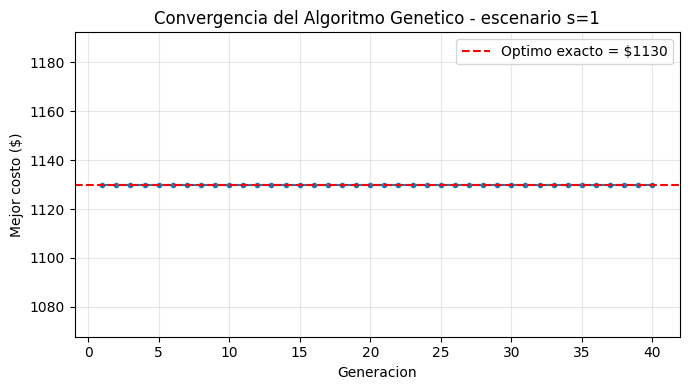

In [5]:

# Convergencia del Algoritmo Genetico
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1,len(hist)+1), hist, marker='o', ms=3)
ax.axhline(res_opt['total'], color='red', ls='--', label=f"Optimo exacto = ${res_opt['total']:.0f}")
ax.set_xlabel("Generacion"); ax.set_ylabel("Mejor costo ($)")
ax.set_title("Convergencia del Algoritmo Genetico - escenario s=1")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


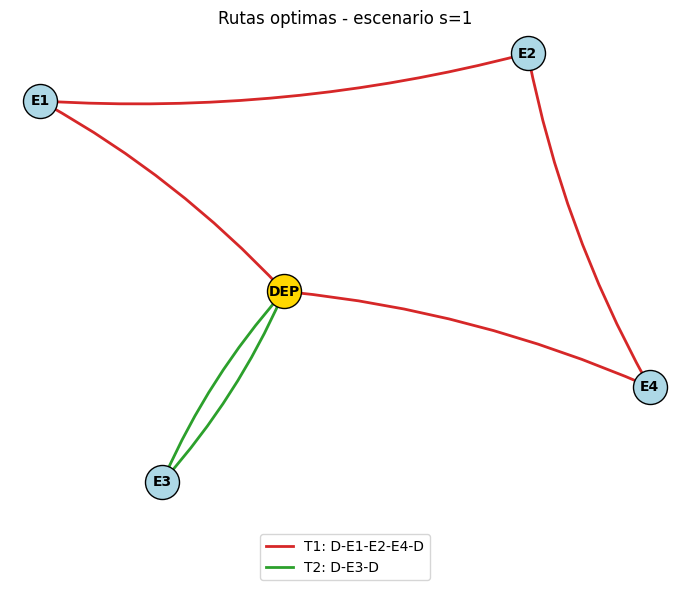

In [6]:

# Visualizacion de las rutas optimas
coords = {0:(0,0), 1:(-2,2), 2:(2,2.5), 3:(-1,-2), 4:(3,-1)}  # layout esquematico
fig, ax = plt.subplots(figsize=(7,6))
for n,(xx,yy) in coords.items():
    ax.scatter(xx,yy,s=600,c='gold' if n==0 else 'lightblue',edgecolors='k',zorder=3)
    ax.text(xx,yy,'DEP' if n==0 else f'E{n}',ha='center',va='center',fontweight='bold',zorder=4)
colors={'T1':'tab:red','T2':'tab:green'}
for tn in ('T1','T2'):
    path=[0]+routes_ga[tn]+[0]
    for i,j in zip(path[:-1],path[1:]):
        x1,y1=coords[i]; x2,y2=coords[j]
        ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->',color=colors[tn],lw=2,
                                    connectionstyle='arc3,rad=0.08'),zorder=2)
    ax.plot([],[],color=colors[tn],lw=2,label=f"{tn}: {'-'.join(['D']+['E'+str(s) for s in routes_ga[tn]]+['D'])}")
ax.legend(loc='upper center',bbox_to_anchor=(0.5,-0.05))
ax.set_title("Rutas optimas - escenario s=1"); ax.axis('off'); plt.tight_layout(); plt.show()


**Interpretación (Parte 1).** El óptimo satisface **toda** la demanda (shortage = 0), usa ambos camiones (su capacidad individual de 15.000 L es insuficiente para los 19.500 L totales) y minimiza la distancia recorrida. El Algoritmo Genético converge al mismo costo que la enumeración exacta, validando la metaheurística. La tabla siguiente detalla la carga y los fill ratios en cada instante para confirmar estabilidad.

In [7]:

# Detalle de carga y estabilidad de la solucion optima
rows=[]
for tn in ('T1','T2'):
    r=res_ga['info'][tn]
    for inst,(f0,f1) in zip(r['instants'], r['fills']):
        rows.append(dict(Camion=tn, Instante=inst,
                         FillC0=f"{f0*100:.1f}%", FillC1=f"{f1*100:.1f}%",
                         Diferencia=f"{abs(f0-f1)*100:.1f}%",
                         OK="en regla" if abs(f0-f1)<=DELTA+1e-9 else "VIOLA"))
display(pd.DataFrame(rows))


,Camion,Instante,FillC0,FillC1,Diferencia,OK
0,T1,Salida deposito,100.0%,85.7%,14.3%,en regla
1,T1,Tras Est.1,62.5%,57.1%,5.4%,en regla
2,T1,Tras Est.2,12.5%,35.7%,23.2%,en regla
3,T1,Tras Est.4,0.0%,0.0%,0.0%,en regla
4,T2,Salida deposito,50.0%,27.8%,22.2%,en regla
5,T2,Tras Est.3,0.0%,0.0%,0.0%,en regla


## Parte 2 — Scheduling de carga en el depósito

**Datos fijos (escenario s=1):**
- T1 carga **5.000 L Regular** (C0) y **5.000 L Diésel** (C1).
- T2 carga **4.000 L Diésel** (C0) y **3.500 L Regular** (C1).

Tasas: Regular **500 L/min**, Diésel **400 L/min**. Una sola **bahía por tipo** de combustible. Limpieza **5 min** al terminar cada compartimento.

### a) Cálculo de tiempos de carga
Tiempo de carga = (volumen / tasa) + 5 min de limpieza.

In [8]:

RATE = {'R':500, 'D':400}; CLEAN = 5
# operaciones: (id, camion, bahia, volumen, producto)
ops = [
    ('T1-C0', 'T1', 'R', 5000, 'R'),   # T1 Regular  -> bahia Regular
    ('T1-C1', 'T1', 'D', 5000, 'D'),   # T1 Diesel   -> bahia Diesel
    ('T2-C0', 'T2', 'D', 4000, 'D'),   # T2 Diesel   -> bahia Diesel
    ('T2-C1', 'T2', 'R', 3500, 'R'),   # T2 Regular  -> bahia Regular
]
proc = {}
rows=[]
for oid, k, bay, vol, p in ops:
    load = vol / RATE[p]; total = load + CLEAN
    proc[oid] = total
    rows.append(dict(Operacion=oid, Camion=k, Bahia=bay, Volumen=vol,
                     Carga_min=load, Limpieza=CLEAN, Total_min=total))
df_proc = pd.DataFrame(rows); display(df_proc)


,Operacion,Camion,Bahia,Volumen,Carga_min,Limpieza,Total_min
0,T1-C0,T1,R,5000,10.0,5,15.0
1,T1-C1,T1,D,5000,12.5,5,17.5
2,T2-C0,T2,D,4000,10.0,5,15.0
3,T2-C1,T2,R,3500,7.0,5,12.0


### b) Formulación del scheduling (makespan)

**Variables:** $s_{k,c}\ge0$ inicio de carga del compartimento $c$ del camión $k$; $C_{max}$ makespan; $y_{ij}\in\{0,1\}=1$ si la operación $i$ precede a $j$ en la misma bahía.

$$\min C_{max}$$

**Precedencia dentro del camión** (el 2º compartimento empieza cuando termina el 1º):
$$s_{k,2}\ge s_{k,1}+p_{k,1}$$

**No-solapamiento en cada bahía** (disjuntivas, $i,j$ en la misma bahía):
$$s_i\ge s_j+p_j-My_{ij},\qquad s_j\ge s_i+p_i-M(1-y_{ij})$$

**Makespan:** $C_{max}\ge s_o+p_o\;\;\forall o$.

Como sólo hay 2 operaciones por bahía y 2 por camión, el espacio es pequeño y se resuelve por **enumeración** del orden en cada bahía y del orden de compartimentos por camión.

In [9]:

# Bahias: Regular = {T1-C0, T2-C1}; Diesel = {T1-C1, T2-C0}
bay_ops = {'R': ['T1-C0','T2-C1'], 'D': ['T1-C1','T2-C0']}
truck_ops = {'T1': ['T1-C0','T1-C1'], 'T2': ['T2-C0','T2-C1']}

def schedule_makespan():
    best = None
    for ordR in itertools.permutations(bay_ops['R']):
        for ordD in itertools.permutations(bay_ops['D']):
            for seqT1 in itertools.permutations(truck_ops['T1']):
                for seqT2 in itertools.permutations(truck_ops['T2']):
                    start = {o:0.0 for o in proc}
                    seqs_truck = {'T1':seqT1, 'T2':seqT2}
                    bay_seq = {'R':ordR, 'D':ordD}
                    for _ in range(20):   # propagacion de restricciones (punto fijo)
                        for k, seq in seqs_truck.items():
                            start[seq[1]] = max(start[seq[1]], start[seq[0]] + proc[seq[0]])
                        for bay, seq in bay_seq.items():
                            start[seq[1]] = max(start[seq[1]], start[seq[0]] + proc[seq[0]])
                    mk = max(start[o] + proc[o] for o in proc)
                    if best is None or mk < best[0]:
                        best = (mk, dict(start), seqs_truck, bay_seq)
    return best

mk, start, seqs_truck, bay_seq = schedule_makespan()
print(f"Makespan optimo = {mk:.1f} min")
print("Cota inferior (carga total de la bahia mas ocupada):",
      max(sum(proc[o] for o in bay_ops[b]) for b in bay_ops), "min")
for o in proc:
    print(f"  {o}: inicio={start[o]:5.1f}  fin={start[o]+proc[o]:5.1f}  (dur {proc[o]})")


Makespan optimo = 32.5 min
Cota inferior (carga total de la bahia mas ocupada): 32.5 min
  T1-C0: inicio=  0.0  fin= 15.0  (dur 15.0)
  T1-C1: inicio= 15.0  fin= 32.5  (dur 17.5)
  T2-C0: inicio=  0.0  fin= 15.0  (dur 15.0)
  T2-C1: inicio= 15.0  fin= 27.0  (dur 12.0)


### c) Secuencia óptima y diagrama de Gantt

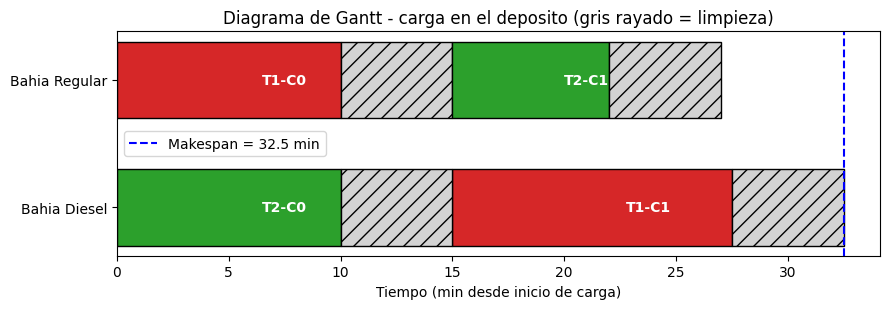

In [10]:

fig, ax = plt.subplots(figsize=(9,3.2))
colors = {'T1':'tab:red','T2':'tab:green'}
bay_y = {'R':10, 'D':0}
for oid, k, bay, vol, p in ops:
    s0 = start[oid]; dur = proc[oid]
    ax.barh(bay_y[bay], dur-CLEAN, left=s0, height=6, color=colors[k], edgecolor='k')
    ax.barh(bay_y[bay], CLEAN, left=s0+dur-CLEAN, height=6, color='lightgray', edgecolor='k', hatch='//')
    ax.text(s0+dur/2, bay_y[bay], oid, ha='center', va='center', color='white', fontweight='bold')
ax.set_yticks([0,10]); ax.set_yticklabels(['Bahia Diesel','Bahia Regular'])
ax.set_xlabel("Tiempo (min desde inicio de carga)")
ax.axvline(mk, color='blue', ls='--', label=f"Makespan = {mk:.1f} min")
ax.set_title("Diagrama de Gantt - carga en el deposito (gris rayado = limpieza)")
ax.legend(); plt.tight_layout(); plt.show()


In [11]:

# Verificacion de salidas a tiempo
print("Verificacion de horas de salida:")
print(f"  Makespan total de carga = {mk:.1f} min.")
for k in ('T1','T2'):
    fin = max(start[o]+proc[o] for o in truck_ops[k])
    print(f"  {k}: termina su carga {fin:.1f} min despues del inicio; sale a las {hhmm(TRUCKS[k]['depart'])}.")
inicio = 4*60  # 04:00
print(f"\nSi la carga inicia a las {hhmm(inicio)}:")
for k in ('T1','T2'):
    fin = inicio + max(start[o]+proc[o] for o in truck_ops[k])
    holg = TRUCKS[k]['depart'] - fin
    print(f"  {k} listo a las {hhmm(fin)} | salida {hhmm(TRUCKS[k]['depart'])} | holgura {holg:.1f} min -> "
          + ("OK" if holg>=0 else "NO ALCANZA"))


Verificacion de horas de salida:
  Makespan total de carga = 32.5 min.
  T1: termina su carga 32.5 min despues del inicio; sale a las 05:00.
  T2: termina su carga 27.0 min despues del inicio; sale a las 05:30.

Si la carga inicia a las 04:00:
  T1 listo a las 04:32 | salida 05:00 | holgura 27.5 min -> OK
  T2 listo a las 04:27 | salida 05:30 | holgura 63.0 min -> OK


**Interpretación (Parte 2).** El cuello de botella es la **bahía de Diésel** (17,5 + 15 = 32,5 min de trabajo), que fija la cota inferior del makespan. La secuencia óptima carga en paralelo ambas bahías: Regular hace `T1-C0 → T2-C1` y Diésel hace `T2-C0 → T1-C1`, alcanzando el **makespan = 32,5 min**, igual a la cota inferior (óptimo). Iniciando la carga a las 04:00, T1 queda listo a las 04:32 (sale 05:00) y T2 a las 04:27 (sale 05:30): **ambos camiones pueden salir a su hora programada**.

## Parte 3 — Análisis de la solución propuesta por el operador

| Camión | Ruta | C0 | C1 | Fill C0 | Fill C1 |
|---|---|---|---|---|---|
| T1 | D→1→3→D | Regular | Diésel | 62.5% | 71.4% |
| T2 | D→2→4→D | Diésel | Regular | 66.7% | 38.9% |

El operador declara: **costo de distancia = \$260** y **shortage = 0**.

Reconstruimos la solución a partir de los fill ratios (volumen cargado = fill × capacidad) y la verificamos numéricamente.

In [12]:

# Reconstruccion de cargas a partir de los fill ratios declarados
# T1: C0=Regular 62.5%*8000=5000 ; C1=Diesel 71.4%*7000=5000
# T2: C0=Diesel 66.7%*6000=4000  ; C1=Regular 38.9%*9000=3500
prop_routes = {'T1':[1,3], 'T2':[2,4]}
prop_orient = {'T1':0, 'T2':1}                       # T1: Regular en C0 ; T2: Regular en C1
prop_loads  = {'T1':(5000,5000), 'T2':(3500,4000)}   # (load_regular, load_diesel)

res_prop = eval_solution(prop_routes, prop_orient, DEM_S1, loads=prop_loads)
print("Cargas reconstruidas (fill ratio x capacidad):")
print("  T1: Regular 5000 L (62.5% de 8000), Diesel 5000 L (71.4% de 7000)")
print("  T2: Regular 3500 L (38.9% de 9000), Diesel 4000 L (66.7% de 6000)")


Cargas reconstruidas (fill ratio x capacidad):
  T1: Regular 5000 L (62.5% de 8000), Diesel 5000 L (71.4% de 7000)
  T2: Regular 3500 L (38.9% de 9000), Diesel 4000 L (66.7% de 6000)


### a) Verificación de factibilidad

**(i) Capacidad de compartimentos** — ¿cabe el volumen a entregar en cada compartimento?

In [13]:

rows=[]
for tn in ('T1','T2'):
    r=res_prop['info'][tn]; order=prop_routes[tn]
    dem_reg=sum(DEM_S1[s][0] for s in order); dem_die=sum(DEM_S1[s][1] for s in order)
    rows.append(dict(Camion=tn, Producto='Regular', Demanda_ruta=dem_reg, Capacidad=int(r['cap_reg']),
                     Cargado=int(r['load_reg']), Cabe="Si" if dem_reg<=r['cap_reg'] else "No"))
    rows.append(dict(Camion=tn, Producto='Diesel', Demanda_ruta=dem_die, Capacidad=int(r['cap_die']),
                     Cargado=int(r['load_die']), Cabe="Si" if dem_die<=r['cap_die'] else "No"))
display(pd.DataFrame(rows))
print("La capacidad de TODOS los compartimentos basta para la demanda de su ruta.")
print("Pero el operador CARGO MENOS que la demanda en Regular (T1: 5000<5500 ; T2: 3500<5000).")


,Camion,Producto,Demanda_ruta,Capacidad,Cargado,Cabe
0,T1,Regular,5500,8000,5000,Si
1,T1,Diesel,5000,7000,5000,Si
2,T2,Regular,5000,9000,3500,Si
3,T2,Diesel,4000,6000,4000,Si


La capacidad de TODOS los compartimentos basta para la demanda de su ruta.
Pero el operador CARGO MENOS que la demanda en Regular (T1: 5000<5500 ; T2: 3500<5000).


**(ii) Estabilidad ($\Delta=0.30$)** — fill ratio de cada compartimento en cada instante.

In [14]:

rows=[]
for tn in ('T1','T2'):
    r=res_prop['info'][tn]
    for inst,(f0,f1) in zip(r['instants'], r['fills']):
        diff=abs(f0-f1)
        rows.append(dict(Camion=tn, Instante=inst, FillC0=f"{f0*100:.1f}%", FillC1=f"{f1*100:.1f}%",
                         Diferencia=f"{diff*100:.1f}%", Estado="OK" if diff<=DELTA+1e-9 else "VIOLA D=30%"))
display(pd.DataFrame(rows))
print("Estabilidad global:", "OK" if res_prop['stab_ok'] else "VIOLADA")


,Camion,Instante,FillC0,FillC1,Diferencia,Estado
0,T1,Salida deposito,62.5%,71.4%,8.9%,OK
1,T1,Tras Est.1,25.0%,42.9%,17.9%,OK
2,T1,Tras Est.3,0.0%,0.0%,0.0%,OK
3,T2,Salida deposito,66.7%,38.9%,27.8%,OK
4,T2,Tras Est.2,41.7%,0.0%,41.7%,VIOLA D=30%
5,T2,Tras Est.4,0.0%,0.0%,0.0%,OK


Estabilidad global: VIOLADA


**(iii) Ventanas de tiempo** — hora de llegada estimada a cada estación (60 km/h, servicio 30 min).

In [15]:

rows=[]
for tn in ('T1','T2'):
    r=res_prop['info'][tn]
    for s in prop_routes[tn]:
        a,b=WIN[s]; arr=r['arrivals'][s]
        if arr> b+1e-6: estado="LLEGA TARDE"
        elif arr< a-1e-6: estado="llega antes (espera)"
        else: estado="dentro de ventana"
        rows.append(dict(Camion=tn, Estacion=f"Est.{s}", Llegada=hhmm(arr),
                         Ventana=f"[{hhmm(a)}-{hhmm(b)}]", Estado=estado))
display(pd.DataFrame(rows))
print("Ventanas (sin llegadas tarde):", "OK" if res_prop['tw_ok'] else "hay llegadas tarde")
print("Nota: varias llegadas son ANTES de a_j; si se permite esperar, son admisibles.")


,Camion,Estacion,Llegada,Ventana,Estado
0,T1,Est.1,05:20,[06:00-10:00],llega antes (espera)
1,T1,Est.3,06:55,[08:00-14:00],llega antes (espera)
2,T2,Est.2,06:05,[07:00-12:00],llega antes (espera)
3,T2,Est.4,07:45,[06:00-11:00],dentro de ventana


Ventanas (sin llegadas tarde): OK
Nota: varias llegadas son ANTES de a_j; si se permite esperar, son admisibles.


### b) Verificación del costo declarado

In [16]:

print("=== COSTO REAL de la solucion propuesta ===")
print(f"  (1) Distancia: T1={res_prop['info']['T1']['dist']:.0f} km + "
      f"T2={res_prop['info']['T2']['dist']:.0f} km = {res_prop['dist']:.0f} km  ->  ${res_prop['dist_cost']:.0f}")
print(f"  (2) Costos fijos: T1 $500 + T2 $400 = ${res_prop['fixed']:.0f}")
print(f"  (3) Shortage: {res_prop['short']:.0f} L de Regular  ->  ${res_prop['short_cost']:.0f}")
print(f"  ------------------------------------------------------")
print(f"  COSTO TOTAL REAL = ${res_prop['total']:.0f}")
print()
print("=== COMPARACION con lo declarado ===")
print(f"  Distancia declarada $260  vs  real ${res_prop['dist_cost']:.0f}  -> ERROR (faltaron 20 km)")
print(f"  Shortage declarado 0 L    vs  real {res_prop['short']:.0f} L  -> ERROR")
print(f"  Ademas el operador OMITE los costos fijos (${res_prop['fixed']:.0f}).")


=== COSTO REAL de la solucion propuesta ===
  (1) Distancia: T1=60 km + T2=90 km = 150 km  ->  $300
  (2) Costos fijos: T1 $500 + T2 $400 = $900
  (3) Shortage: 2000 L de Regular  ->  $20000
  ------------------------------------------------------
  COSTO TOTAL REAL = $21200

=== COMPARACION con lo declarado ===
  Distancia declarada $260  vs  real $300  -> ERROR (faltaron 20 km)
  Shortage declarado 0 L    vs  real 2000 L  -> ERROR
  Ademas el operador OMITE los costos fijos ($900).


**Conclusión 3a–3b.**
- **Capacidad:** todos los compartimentos podrían contener la demanda de su ruta, pero el operador **cargó de menos** el Regular.
- **Estabilidad:** **T1 cumple** (diferencia máx. 17,9%); **T2 VIOLA** la restricción: tras entregar en Est.2 el Regular cae a 0% mientras el Diésel queda en 41,7% (diferencia 41,7% > 30%).
- **Ventanas:** no hay llegadas *tarde*; varias llegadas son *anticipadas* (admisibles sólo si se permite esperar).
- **Costo declarado FALSO:** la distancia real es **\$300** (no \$260) y existe **shortage de 2.000 L de Regular** (T1: 500 L + T2: 1.500 L) = **\$20.000**; además omite **\$900** de costos fijos.

### c) Propuesta de mejora

In [17]:

# Mejora: (1) cargar Regular hasta cubrir la demanda (hay capacidad);
#         (2) invertir la ruta de T2 a D->4->2->D para respetar la estabilidad.
print("Si solo se carga mas (sin cambiar la ruta de T2):")
imp_loads = {'T1':(5500,5000), 'T2':(5000,4000)}
res_a = eval_solution(prop_routes, prop_orient, DEM_S1, loads=imp_loads)
print(f"  estabilidad OK={res_a['stab_ok']}  (sigue violando: el Regular de T2 baja mucho tras Est.2)")

print("\nMEJORA propuesta: cargar a demanda + invertir ruta de T2 (D->4->2->D):")
imp_routes = {'T1':[1,3], 'T2':[4,2]}
res_imp = eval_solution(imp_routes, prop_orient, DEM_S1, loads=imp_loads)
for tn in ('T1','T2'):
    r=res_imp['info'][tn]
    diffs=[abs(f0-f1) for f0,f1 in r['fills']]
    print(f"  {tn}: ruta D->{'->'.join(str(s) for s in imp_routes[tn])}->D | "
          f"dif. estabilidad max={max(diffs)*100:.1f}% | tarde={r['late']}")
print(f"\n  Costo: distancia ${res_imp['dist_cost']:.0f} + fijo ${res_imp['fixed']:.0f} + "
      f"shortage ${res_imp['short_cost']:.0f} = ${res_imp['total']:.0f}")
print(f"  Factible: estabilidad={res_imp['stab_ok']}, ventanas={res_imp['tw_ok']}")
print(f"\n  Reduccion de costo vs. solucion del operador: "
      f"${res_prop['total']:.0f} -> ${res_imp['total']:.0f}  (ahorro ${res_prop['total']-res_imp['total']:.0f})")


Si solo se carga mas (sin cambiar la ruta de T2):
  estabilidad OK=False  (sigue violando: el Regular de T2 baja mucho tras Est.2)

MEJORA propuesta: cargar a demanda + invertir ruta de T2 (D->4->2->D):
  T1: ruta D->1->3->D | dif. estabilidad max=11.6% | tarde=False
  T2: ruta D->4->2->D | dif. estabilidad max=19.4% | tarde=False

  Costo: distancia $300 + fijo $900 + shortage $0 = $1200
  Factible: estabilidad=True, ventanas=True

  Reduccion de costo vs. solucion del operador: $21200 -> $1200  (ahorro $20000)


**Mejora (3c).** Dos cambios *factibles*:
1. **Cargar el Regular hasta la demanda** (hay capacidad ociosa): T1 → 5.500 L (68,75% de 8.000) y T2 → 5.000 L (55,6% de 9.000). Esto **elimina los \$20.000 de shortage**.
2. **Invertir la ruta de T2** a `D→4→2→D` (misma distancia, 90 km). Entregar primero en Est.4 mantiene el balance de fill ratios y **respeta la estabilidad** en todo instante, cosa que la ruta original no lograba.

Resultado: solución **factible** en estabilidad y ventanas, con costo total **\$1.200** frente a los **\$21.200** reales de la propuesta original, un ahorro de **\$20.000**. Manteniendo la asignación de estaciones del operador, \$1.200 es lo mejor alcanzable; el **óptimo global** de la Parte 1, que reasigna las estaciones —T1 sirve las estaciones 1, 2 y 4, y T2 sólo la 3—, es aún menor: **\$1.130**.

## Parte 4 — Extensión estocástica de dos etapas

La demanda es incierta; se consideran 3 escenarios. Est.4 es fija; en Est.3 sólo se informa la variación del Regular (su Diésel se mantiene en el valor base **3.000 L** — supuesto declarado).

| Escenario | Prob. | E1 (R,D) | E2 (R,D) | E3 (R,D) | E4 (R,D) |
|---|---|---|---|---|---|
| s=1 Normal | 0.5 | (3000,2000) | (4000,1500) | (2500,3000) | (1000,2500) |
| s=2 Alta   | 0.3 | (4500,2800) | (5500,2000) | (3500,3000) | (1000,2500) |
| s=3 Baja   | 0.2 | (2000,1200) | (3000,1000) | (1800,3000) | (1000,2500) |

### a) Modelo de dos etapas

**Decisiones de PRIMERA etapa (here-and-now, antes de conocer la demanda):**
- $z_k$ uso de camión, $x_{ijk}$ rutas, $\alpha_{kmp}$ asignación compartimento–producto y **volúmenes de carga** $L_{kmp}$. Se cargan en el depósito *antes* de salir, por lo que **no** pueden depender del escenario.

**Decisiones de SEGUNDA etapa (recourse, tras observar la demanda $\xi_s$):**
- entregas $q_{jkp}^{s}$ y shortage $w_{jp}^{s}$ en cada escenario. La estabilidad y las ventanas se evalúan sobre las entregas realizadas en cada escenario.

**Función objetivo** — costo de primera etapa más el **valor esperado** del recourse:
$$\min\;\sum_k F_k z_k \;+\; cf\sum_{i,j,k} d_{ij}x_{ijk}\;+\;\sum_{s} P_s\Big(cs\sum_{j,p} w_{jp}^{s}\Big)$$

Los costos fijos y de distancia son de primera etapa (idénticos en todos los escenarios); el costo de shortage es de segunda etapa (esperado sobre los escenarios).

### b) Resolución con la metaheurística
Primera etapa: rutas + orientación + cargas $L=\min(\text{cap},\,\max_s \text{demanda asignada})$ (planificar para el escenario alto, acotado por capacidad). Segunda etapa: entregas y shortage por escenario. Se optimizan rutas/asignación por **costo esperado** con el mismo Algoritmo Genético.

In [18]:

SCEN = {
    's1': dict(p=0.5, dem={1:(3000,2000),2:(4000,1500),3:(2500,3000),4:(1000,2500)}),
    's2': dict(p=0.3, dem={1:(4500,2800),2:(5500,2000),3:(3500,3000),4:(1000,2500)}),
    's3': dict(p=0.2, dem={1:(2000,1200),2:(3000,1000),3:(1800,3000),4:(1000,2500)}),
}

def first_stage_loads(routes, orient):
    # Carga de 1a etapa = min(capacidad, maxima demanda asignada entre escenarios).
    loads={}
    for tn,order in routes.items():
        if not order: continue
        reg=max(sum(SCEN[s]['dem'][j][0] for j in order) for s in SCEN)
        die=max(sum(SCEN[s]['dem'][j][1] for j in order) for s in SCEN)
        loads[tn]=(reg,die)
    return loads

def expected_cost(routes, orient):
    loads=first_stage_loads(routes, orient)
    base=eval_solution(routes, orient, SCEN['s1']['dem'], loads=loads)
    first=base['dist_cost']+base['fixed']
    exp_short=0.0; stab_all=True; tw_all=True; per=[]
    for s,info in SCEN.items():
        r=eval_solution(routes, orient, info['dem'], loads=loads)
        exp_short+=info['p']*r['short_cost']
        stab_all=stab_all and r['stab_ok']; tw_all=tw_all and r['tw_ok']
        per.append(dict(Escenario=s, Prob=info['p'], Shortage_L=r['short'],
                        Costo_shortage=r['short_cost'], EstabOK=r['stab_ok'], VentOK=r['tw_ok']))
    return first+exp_short, first, exp_short, stab_all, tw_all, per, loads

def fitness_sto(genome):
    routes,orient=decode(genome, SCEN['s1']['dem'])
    ec,_,_,stab,tw,_,_=expected_cost(routes,orient)
    pen=0 if (stab and tw) else 1e7
    return ec+pen, routes, orient

def ga_stochastic(pop=30, gens=40, pm=0.15, seed=3):
    rng=random.Random(seed)
    pop_list=[[rng.randint(0,1) for _ in range(6)] for _ in range(pop)]
    best=None; hist=[]
    for g in range(gens):
        scored=sorted(((fitness_sto(ind)[0],ind) for ind in pop_list), key=lambda x:x[0])
        if best is None or scored[0][0]<best[0]: best=(scored[0][0], list(scored[0][1]))
        hist.append(best[0])
        new=[list(scored[0][1]),list(scored[1][1])]
        def tour():
            a,b=rng.choice(scored),rng.choice(scored); return a[1] if a[0]<b[0] else b[1]
        while len(new)<pop:
            p1,p2=tour(),tour()
            c=[p1[i] if rng.random()<0.5 else p2[i] for i in range(6)]
            c=[(1-b) if rng.random()<pm else b for b in c]
            new.append(c)
        pop_list=new
    routes,orient=decode(best[1], SCEN['s1']['dem'])
    return best,hist,routes,orient

best_s,hist_s,routes_s,orient_s=ga_stochastic()
ec,first,exp_short,stab,tw,per,loads_s=expected_cost(routes_s,orient_s)

print("===== SOLUCION ESTOCASTICA DE DOS ETAPAS (1a etapa) =====")
for tn in ('T1','T2'):
    if routes_s[tn]:
        rc='C0' if orient_s[tn]==0 else 'C1'
        print(f"  {tn}: D->{'->'.join('E'+str(s) for s in routes_s[tn])}->D | Regular en {rc} | "
              f"carga (Reg,Die)={tuple(int(x) for x in loads_s[tn])}")
print(f"\n  Costo 1a etapa (fijo+distancia) = ${first:.0f}")
print(f"  Costo esperado de shortage (2a etapa) = ${exp_short:.0f}")
print(f"  >> COSTO TOTAL ESPERADO = ${ec:.0f}")
display(pd.DataFrame(per))


===== SOLUCION ESTOCASTICA DE DOS ETAPAS (1a etapa) =====
  T1: D->E2->E4->D | Regular en C0 | carga (Reg,Die)=(6500, 4500)
  T2: D->E1->E3->D | Regular en C1 | carga (Reg,Die)=(8000, 5800)

  Costo 1a etapa (fijo+distancia) = $1200
  Costo esperado de shortage (2a etapa) = $0
  >> COSTO TOTAL ESPERADO = $1200


,Escenario,Prob,Shortage_L,Costo_shortage,EstabOK,VentOK
0,s1,0.5,0.0,0.0,True,True
1,s2,0.3,0.0,0.0,True,True
2,s3,0.2,0.0,0.0,True,True


Costo esperado de la solucion (recourse)        : $1200
Costo 'wait-and-see' (informacion perfecta, WS) : $1151
EVPI (valor esperado de la informacion perfecta): $49


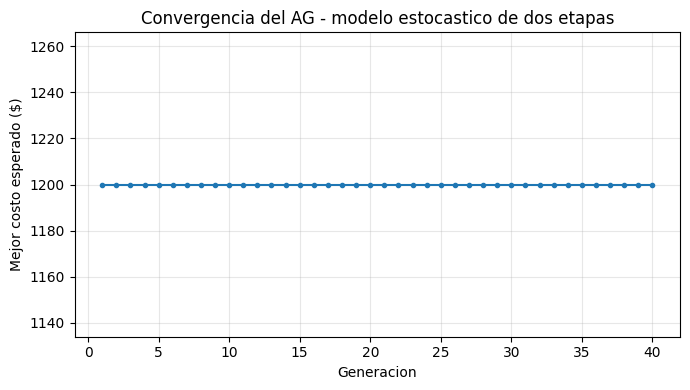

In [19]:

# Comparacion: solucion estocastica vs valor 'wait-and-see' (informacion perfecta) -> EVPI
ws=0.0
for s,info in SCEN.items():
    _,_,_,res=solve_exact(info['dem'])
    ws+=info['p']*res['total']
print(f"Costo esperado de la solucion (recourse)        : ${ec:.0f}")
print(f"Costo 'wait-and-see' (informacion perfecta, WS) : ${ws:.0f}")
print(f"EVPI (valor esperado de la informacion perfecta): ${ec-ws:.0f}")

fig,ax=plt.subplots(figsize=(7,4))
ax.plot(range(1,len(hist_s)+1),hist_s,marker='o',ms=3)
ax.set_xlabel("Generacion"); ax.set_ylabel("Mejor costo esperado ($)")
ax.set_title("Convergencia del AG - modelo estocastico de dos etapas")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


**Interpretación (Parte 4).** La solución de dos etapas fija rutas, asignación y **cargas** *antes* de conocer la demanda, cargando para el escenario alto hasta donde la capacidad lo permite. El recourse absorbe la incertidumbre vía shortage: en el escenario **Alta (s=2)** la demanda de Regular (14.500 L) supera la capacidad de Regular de la flota y aparece shortage; en **Normal** y **Baja** la demanda se satisface. El **EVPI** cuantifica cuánto se ganaría si la demanda se conociera de antemano: es el sobrecosto que impone la incertidumbre y justifica medidas como capacidad de reserva o contratos flexibles.

---
## Conclusiones generales

- La metaheurística (**Algoritmo Genético**) resuelve el ruteo con compartimentos, estabilidad y ventanas, y **coincide con el óptimo exacto** en el caso determinista (validación cruzada).
- El **scheduling de carga** alcanza un makespan de **32,5 min** (igual a la cota inferior), permitiendo que ambos camiones salgan a su hora.
- La solución del operador (Parte 3) es **infactible** (viola estabilidad en T2) y su costo declarado es **falso**: el costo real (\$21.200) está dominado por **\$20.000 de shortage**; una mejora simple lo reduce a **\$1.200**.
- El **modelo estocástico de dos etapas** separa decisiones here-and-now (rutas/cargas) de recourse (entregas/shortage) y cuantifica el impacto de la incertidumbre mediante el costo esperado y el EVPI.
